<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/iTunes_Music_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# iTunes Music Dataset

## Unveiling Insights from the iTunes Music Dataset

Our journey through the iTunes Music Dataset, comprising over 4,900 tracks, has revealed fascinating trends and characteristics within the digital music landscape. The dataset provides a rich tapestry of information, including `track_id`, `track_name`, `artist_name`, `collection_name`, `genre`, `rating`, `track_price`, `collection_price`, `release_date`, `track_time_millis`, `country`, `currency`, `preview_url`, and `artwork_url`.

### Data Preparation: Setting the Stage for Discovery

Before diving into analysis, a crucial step was data preparation. We addressed missing values, particularly in `artist_name`, `preview_url`, `track_price`, `collection_price`, and `release_date`, by either dropping a minimal number of rows or imputing with median values to maintain data integrity. We also enriched the dataset with new, more human-friendly features:

*   **`track_duration_mins`**: Converting milliseconds to understandable minutes.
*   **`release_year`**: Extracting the year from the `release_date` for historical trend analysis.
*   **`price_per_minute`**: Calculating the cost-effectiveness of a track, revealing how much a listener pays for each minute of music.

### Key Insights: What the Data Tells Us

#### 1. The "TikTok Effect" is Real: Songs Are Getting Shorter

One of the most compelling insights comes from analyzing track duration over time. A Pearson Correlation analysis confirmed a statistically significant negative correlation (coefficient: -0.1171, P-Value: 2.5270e-16) between `release_year` and `track_duration_mins`. This suggests a clear trend: **as the years progress, song lengths are indeed getting shorter**. This phenomenon, often dubbed the "TikTok Effect," points to an evolving listener preference for more concise and immediately engaging content in the streaming era.

#### 2. Genre Dictates Song Length

Beyond just time, our ANOVA (Analysis of Variance) test on the top 5 genres (`Bollywood`, `Pop`, `R&B/Soul`, `Hip-Hop/Rap`, `Rock`) revealed that **genre heavily dictates how long a song will be** (ANOVA P-Value: 2.2874e-31). This means that a track's style isn't just about its sound, but also its typical runtime, reflecting different artistic expressions and listener expectations across music categories.

#### 3. AI Can Predict Genre, Mostly by Duration

We trained a Random Forest Classifier to predict a song's genre (`Bollywood`, `Pop`, `R&B/Soul`) based solely on `track_duration_mins`, `release_year`, and `track_price`. The model achieved an **overall accuracy of 67.71%**, demonstrating that these numerical features provide significant clues about a song's genre.

Crucially, **`track_duration_mins` emerged as the most important feature** in the AI's decision-making process, followed by `release_year` and then `track_price`. This reinforces our earlier finding from the ANOVA test: song length is a powerful indicator of genre.

### In Summary

The iTunes Music Dataset offers a fascinating glimpse into the characteristics of digital music. We've seen how track lengths are shrinking over time, likely influenced by changing consumption habits, and how deeply a song's genre is tied to its duration. Furthermore, simple numerical features can be surprisingly effective in classifying music genres, with track duration standing out as the most informative characteristic. These insights can be invaluable for understanding music trends, optimizing content creation, and developing more sophisticated recommendation systems.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ashyou09/itunes-music-dataset

# Unziping the downloaded file
!unzip itunes-music-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ashyou09/itunes-music-dataset
License(s): MIT
  0% 0.00/556k [00:00<?, ?B/s]
100% 556k/556k [00:00<00:00, 1.37GB/s]
Archive:  itunes-music-dataset.zip
  inflating: itunes_music_dataset.csv  


# Data Inspection

In [ ]:
df = pd.read_csv('itunes_music_dataset.csv')
df.head(11)

,track_id,track_name,artist_name,collection_name,album_artist,genre,rating,track_price,collection_price,release_date,track_time_millis,country,currency,preview_url,artwork_url
0,1624932774,POP!,NAYEON,IM NAYEON,NaN,Dance,Clean,1.29,6.99,2022-06-24T12:00:00Z,168107,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
1,1022164261,Riptide,Vance Joy,Dream Your Life Away (Special Edition),NaN,Alternative,Clean,1.29,9.99,2013-03-22T07:00:00Z,202019,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
2,1207120448,Something Just Like This,The Chainsmokers & Coldplay,Memories...Do Not Open,The Chainsmokers,Dance,Clean,1.29,9.99,2017-02-22T08:00:00Z,247165,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
3,1369380479,lovely,Billie Eilish & Khalid,lovely - Single,NaN,Pop,Clean,1.29,1.29,2018-04-19T12:00:00Z,200187,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4,1450695872,when the party's over,Billie Eilish,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",NaN,Alternative,Clean,1.29,10.99,2018-10-17T07:00:00Z,196077,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
5,1440899467,ocean eyes,Billie Eilish,dont smile at me,NaN,Alternative,Clean,1.29,8.99,2016-05-18T12:00:00Z,200379,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
6,1468058171,Cruel Summer,Taylor Swift,Lover,NaN,Pop,Clean,1.29,11.99,2019-08-23T07:00:00Z,178426,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
7,303178994,Pop,*NSYNC,Celebrity,NaN,Pop,Clean,1.29,9.99,2001-07-24T07:00:00Z,238427,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
8,1691699836,Lose Control,Teddy Swims,I've Tried Everything But Therapy (Part 1),NaN,Pop,Clean,1.29,9.99,2023-06-23T12:00:00Z,210689,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
9,573962555,When I Was Your Man,Bruno Mars,Unorthodox Jukebox,NaN,Pop,Clean,1.29,10.99,2012-12-07T08:00:00Z,213827,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...


In [ ]:
df.tail(11)

,track_id,track_name,artist_name,collection_name,album_artist,genre,rating,track_price,collection_price,release_date,track_time_millis,country,currency,preview_url,artwork_url
4904,1440745246,Day 'n' Nite,Kid Cudi,Man On the Moon: The End of Day,NaN,Hip-Hop/Rap,Clean,1.29,9.99,2008-02-05T12:00:00Z,221267,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4905,1065973980,Wish You Were Here,Pink Floyd,Wish You Were Here,NaN,Rock,Clean,1.29,12.99,1975-09-12T07:00:00Z,338467,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4906,1443711628,Kiss Me Thru the Phone (feat. Sammie),Soulja Boy Tell 'Em,iSouljaBoyTellem (Deluxe Version),NaN,Hip-Hop/Rap,Clean,1.29,10.99,2008-01-01T12:00:00Z,193387,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4907,1817507871,"Ye Vaada (From ""Professor Pyarelal"")",Mohd. Rafi & Asha Bhosle,Old Hindi Songs - Vol.1,Kishore Kumar,Soundtrack,Clean,NaN,NaN,2007-01-01T12:00:00Z,288467,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4908,1810515850,Echoes Of Love Old Hindi Song,India Sangeet,Old Hindi Songs,NaN,Worldwide,Clean,0.99,9.99,2025-04-22T12:00:00Z,200342,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4909,30372391,Twisted,Keith Sweat,Keith Sweat,NaN,R&B/Soul,Clean,1.29,9.99,1996-06-04T07:00:00Z,260667,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4910,712330693,I Got 5 On It (feat. Michael Marshall),Luniz,Operation Stackola,NaN,Hip-Hop/Rap,Clean,1.29,7.99,1995-05-23T07:00:00Z,253533,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4911,1817490073,Dekh Lo Awaz Dekar (Prem Geet / Soundtrack Ver...,Anuradha Paudwal,Old Hindi Songs - Vol.2,Kishore Kumar & Asha Bhosle,Soundtrack,Clean,NaN,NaN,1981-01-01T12:00:00Z,355067,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4912,1817490077,Khwabon Ko (Prem Geet / Soundtrack Version),Suresh Wadkar,Old Hindi Songs - Vol.2,Kishore Kumar & Asha Bhosle,Soundtrack,Clean,NaN,NaN,1981-01-01T12:00:00Z,232027,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4913,1817490076,"Suhani Sham Aayi Hai (From ""Shaukeeen"")",Asha Bhosle & R.D. Burman,Old Hindi Songs - Vol.2,Kishore Kumar & Asha Bhosle,Soundtrack,Clean,NaN,NaN,1982-01-01T12:00:00Z,283403,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...


In [ ]:
df.shape

(4915, 15)

In [ ]:
df.columns

Index(['track_id', 'track_name', 'artist_name', 'collection_name',
       'album_artist', 'genre', 'rating', 'track_price', 'collection_price',
       'release_date', 'track_time_millis', 'country', 'currency',
       'preview_url', 'artwork_url'],
      dtype='object')

In [ ]:
df.dtypes

,0
track_id,int64
track_name,object
artist_name,object
collection_name,object
album_artist,object
genre,object
rating,object
track_price,float64
collection_price,float64
release_date,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_id           4915 non-null   int64  
 1   track_name         4915 non-null   object 
 2   artist_name        4913 non-null   object 
 3   collection_name    4915 non-null   object 
 4   album_artist       1728 non-null   object 
 5   genre              4915 non-null   object 
 6   rating             4915 non-null   object 
 7   track_price        4540 non-null   float64
 8   collection_price   4539 non-null   float64
 9   release_date       4867 non-null   object 
 10  track_time_millis  4915 non-null   int64  
 11  country            4915 non-null   object 
 12  currency           4915 non-null   object 
 13  preview_url        4914 non-null   object 
 14  artwork_url        4915 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 576.1+ KB


In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,4915.0,NaN,NaN,NaN,1363644601.304171,425000413.921619,6920394.0,1270555675.5,1445041440.0,1650841729.5,1874863140.0
track_name,4915,4184,Focus,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist_name,4913,2347,Taylor Swift,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collection_name,4915,2810,Top Hits 2024,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_artist,1728,406,Various Artists,581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,4915,97,Bollywood,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,4915,1,Clean,4915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_price,4540.0,NaN,NaN,NaN,1.197784,0.238723,-1.0,1.29,1.29,1.29,1.29
collection_price,4539.0,NaN,NaN,NaN,8.622703,5.748893,-1.0,4.99,9.99,10.99,119.99
release_date,4867,2696,2020-07-20T07:00:00Z,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

,0
track_id,0
track_name,0
artist_name,2
collection_name,0
album_artist,3187
genre,0
rating,0
track_price,375
collection_price,376
release_date,48


### Handling Missing values

In [ ]:
df.drop('album_artist', axis = 1, inplace = True)
df.isnull().sum()

,0
track_id,0
track_name,0
artist_name,2
collection_name,0
genre,0
rating,0
track_price,375
collection_price,376
release_date,48
track_time_millis,0


In [ ]:
# For numerical columns, we might impute with the mean or median
for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

# For categorical columns, we might impute with the mode or a constant
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after handling:")
df.isnull().sum()


Missing values after handling:


,0
track_id,0
track_name,0
artist_name,0
collection_name,0
genre,0
rating,0
track_price,0
collection_price,0
release_date,0
track_time_millis,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Multivariate Analysis


Analyzing relationships with Hue: rating...


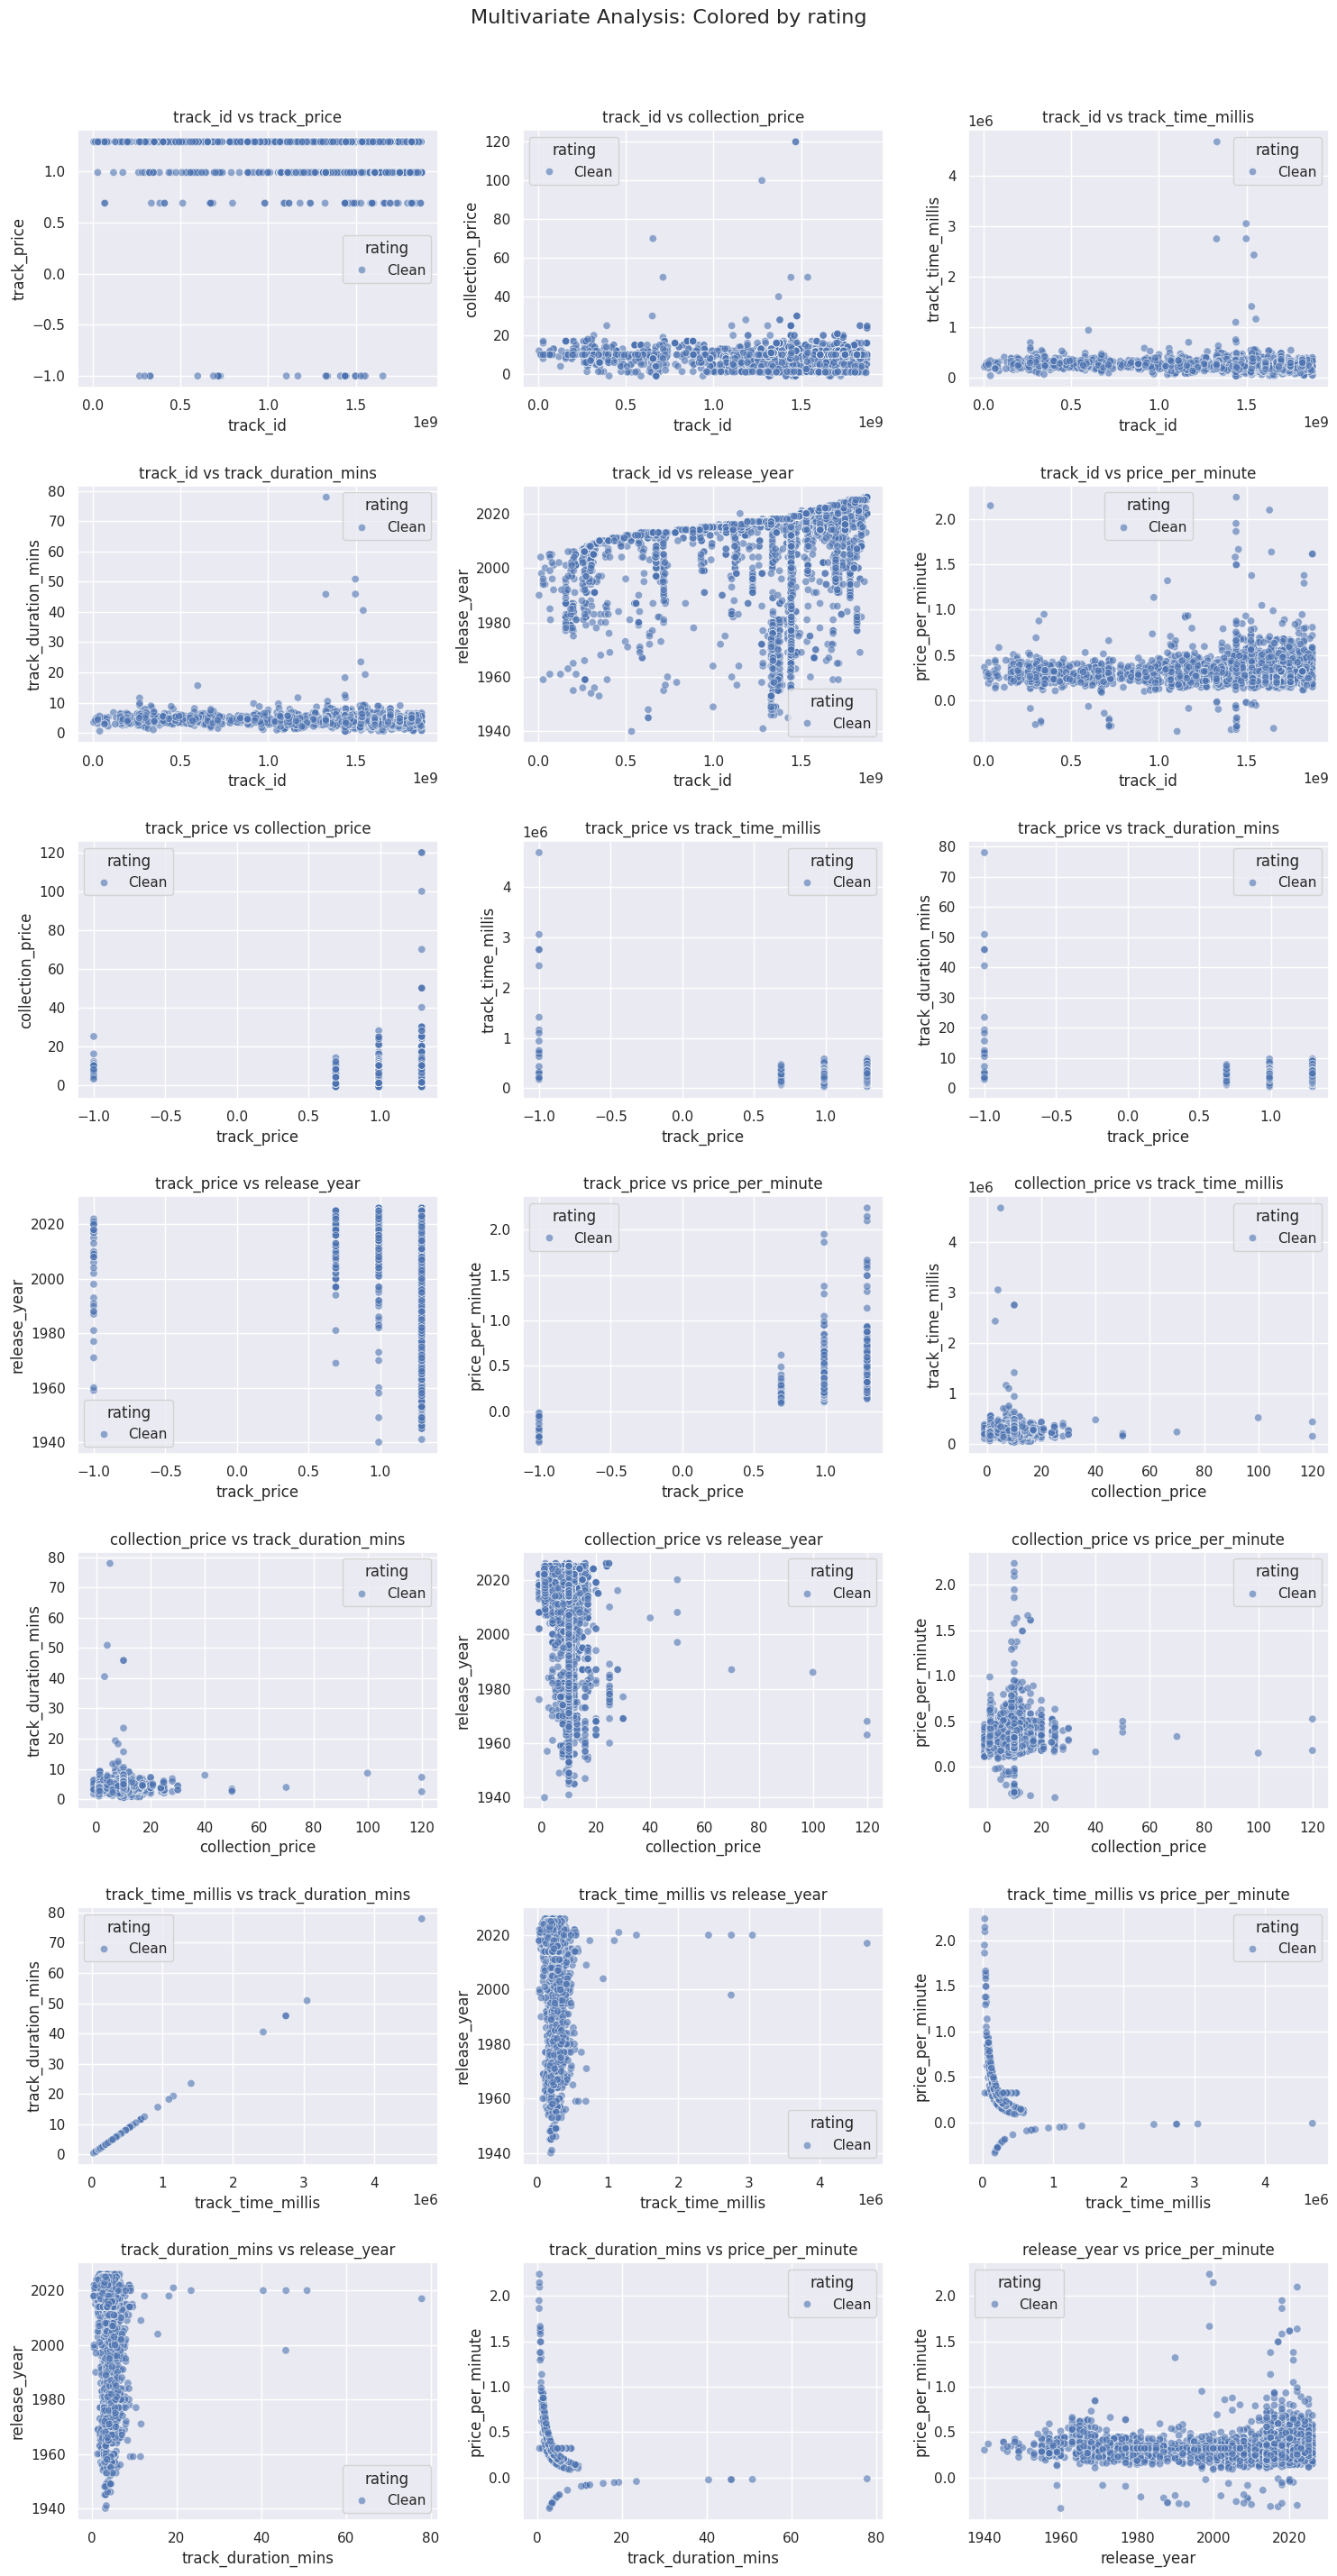


Analyzing relationships with Hue: country...


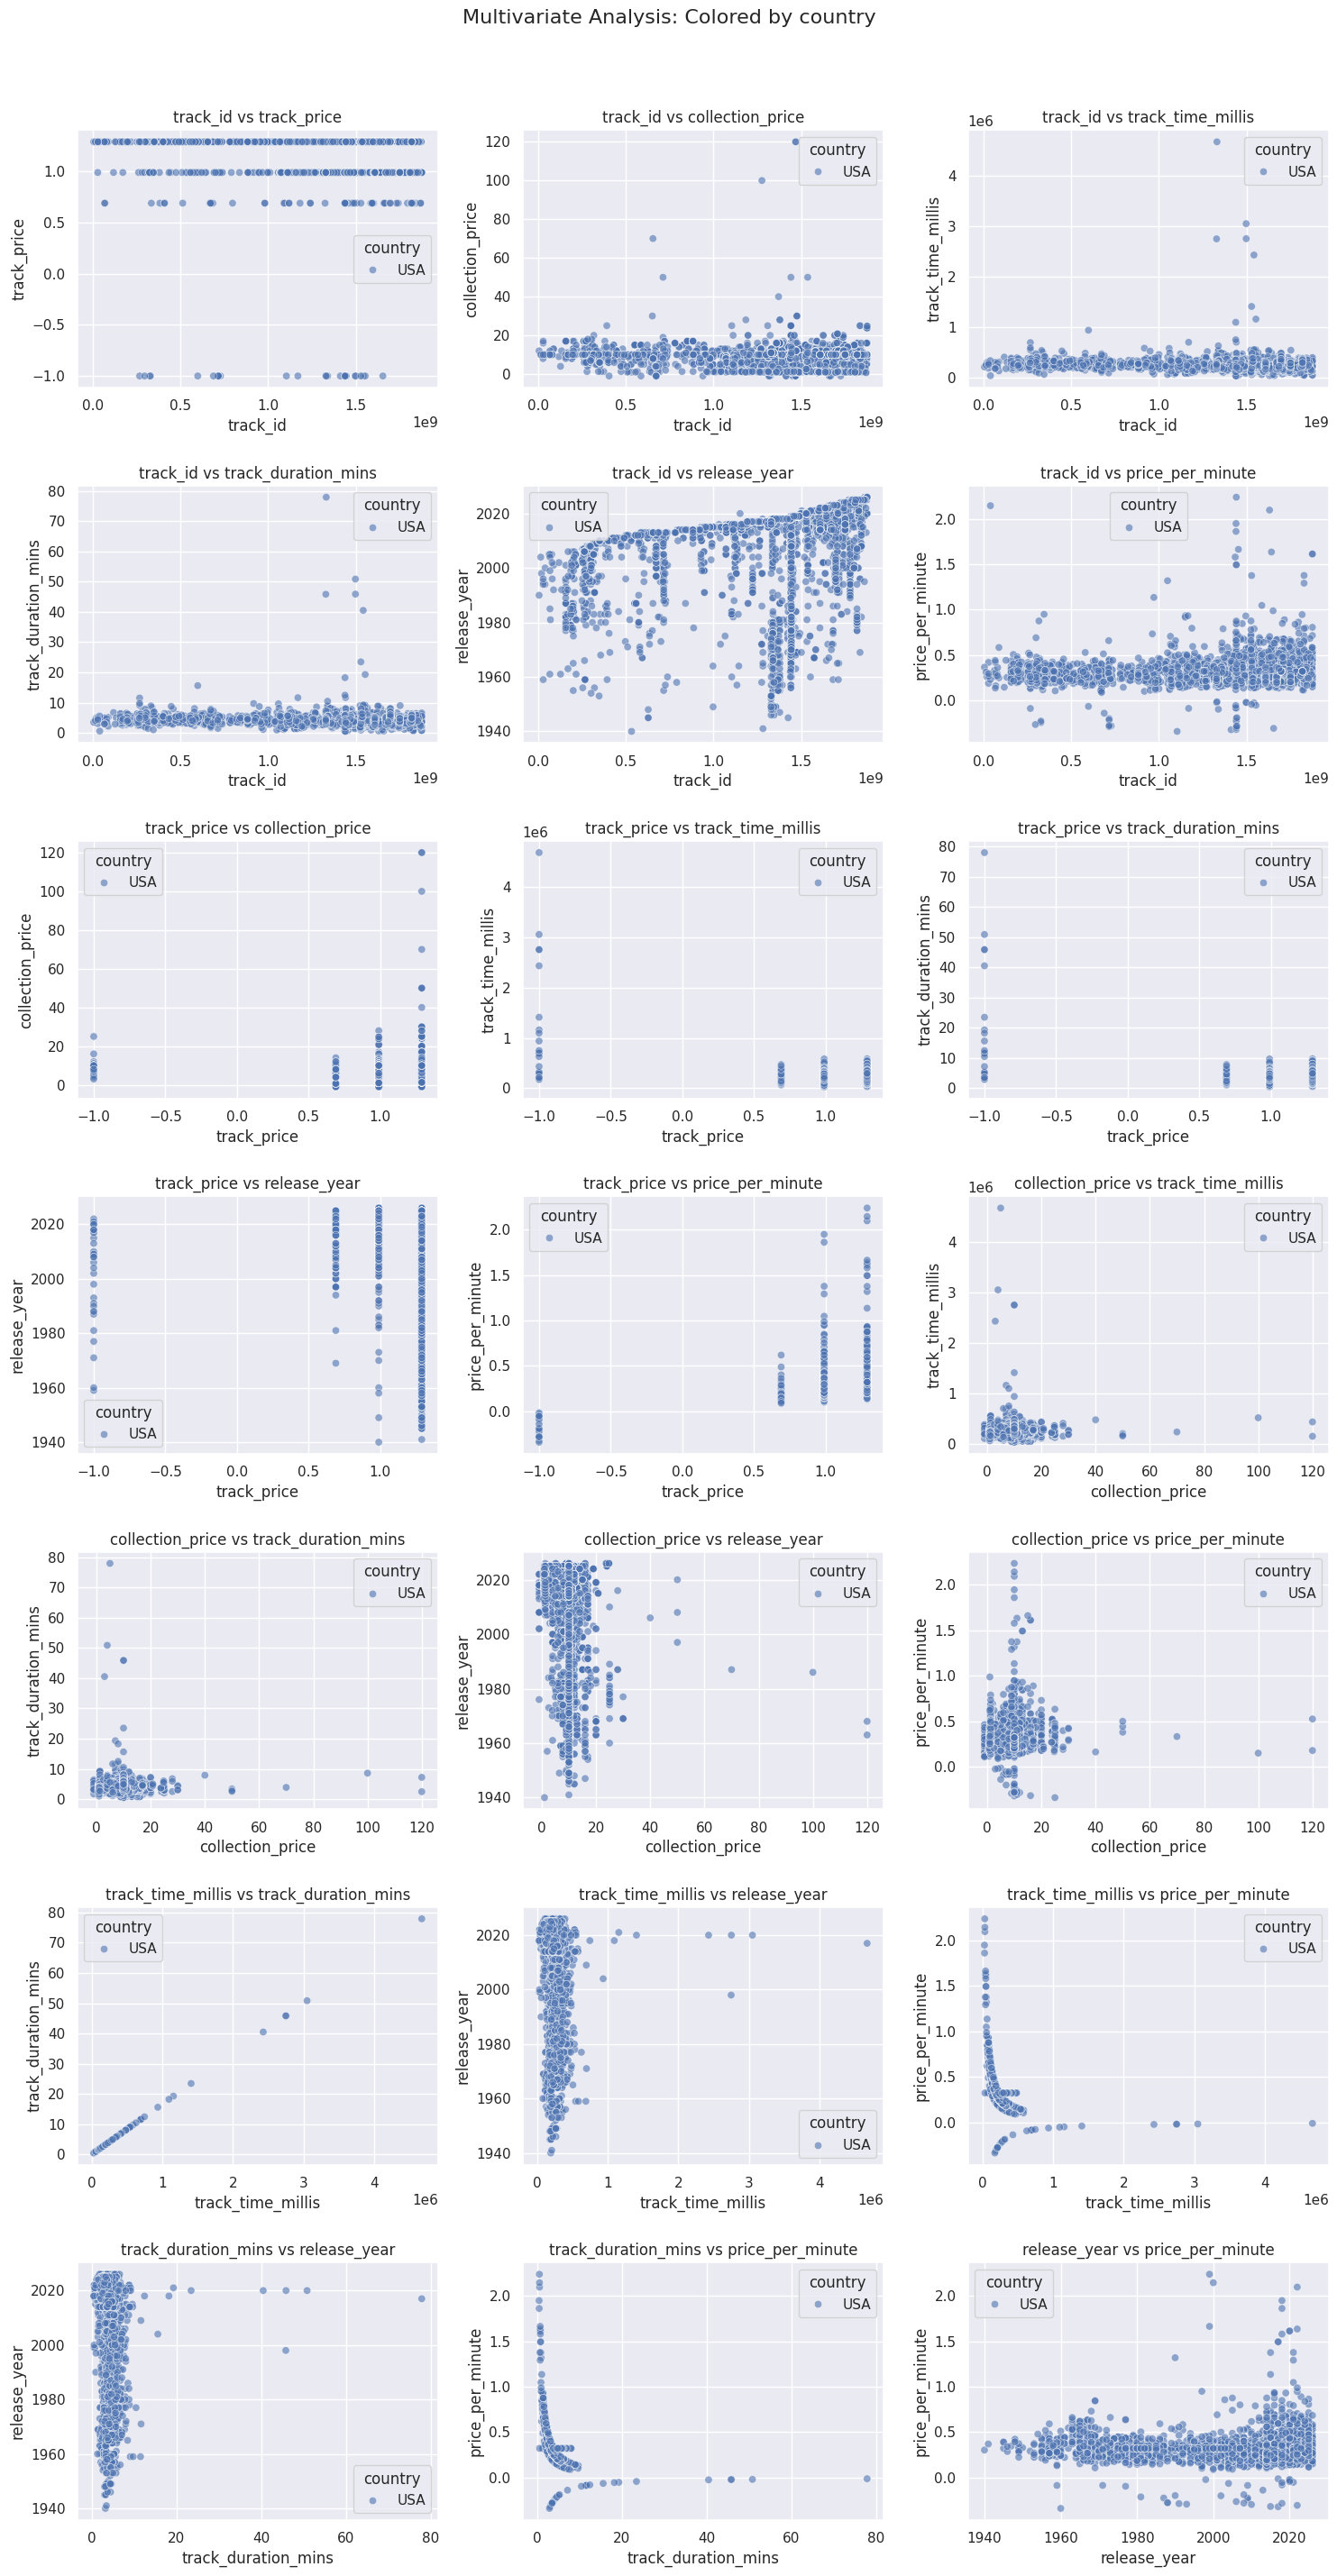


Analyzing relationships with Hue: currency...


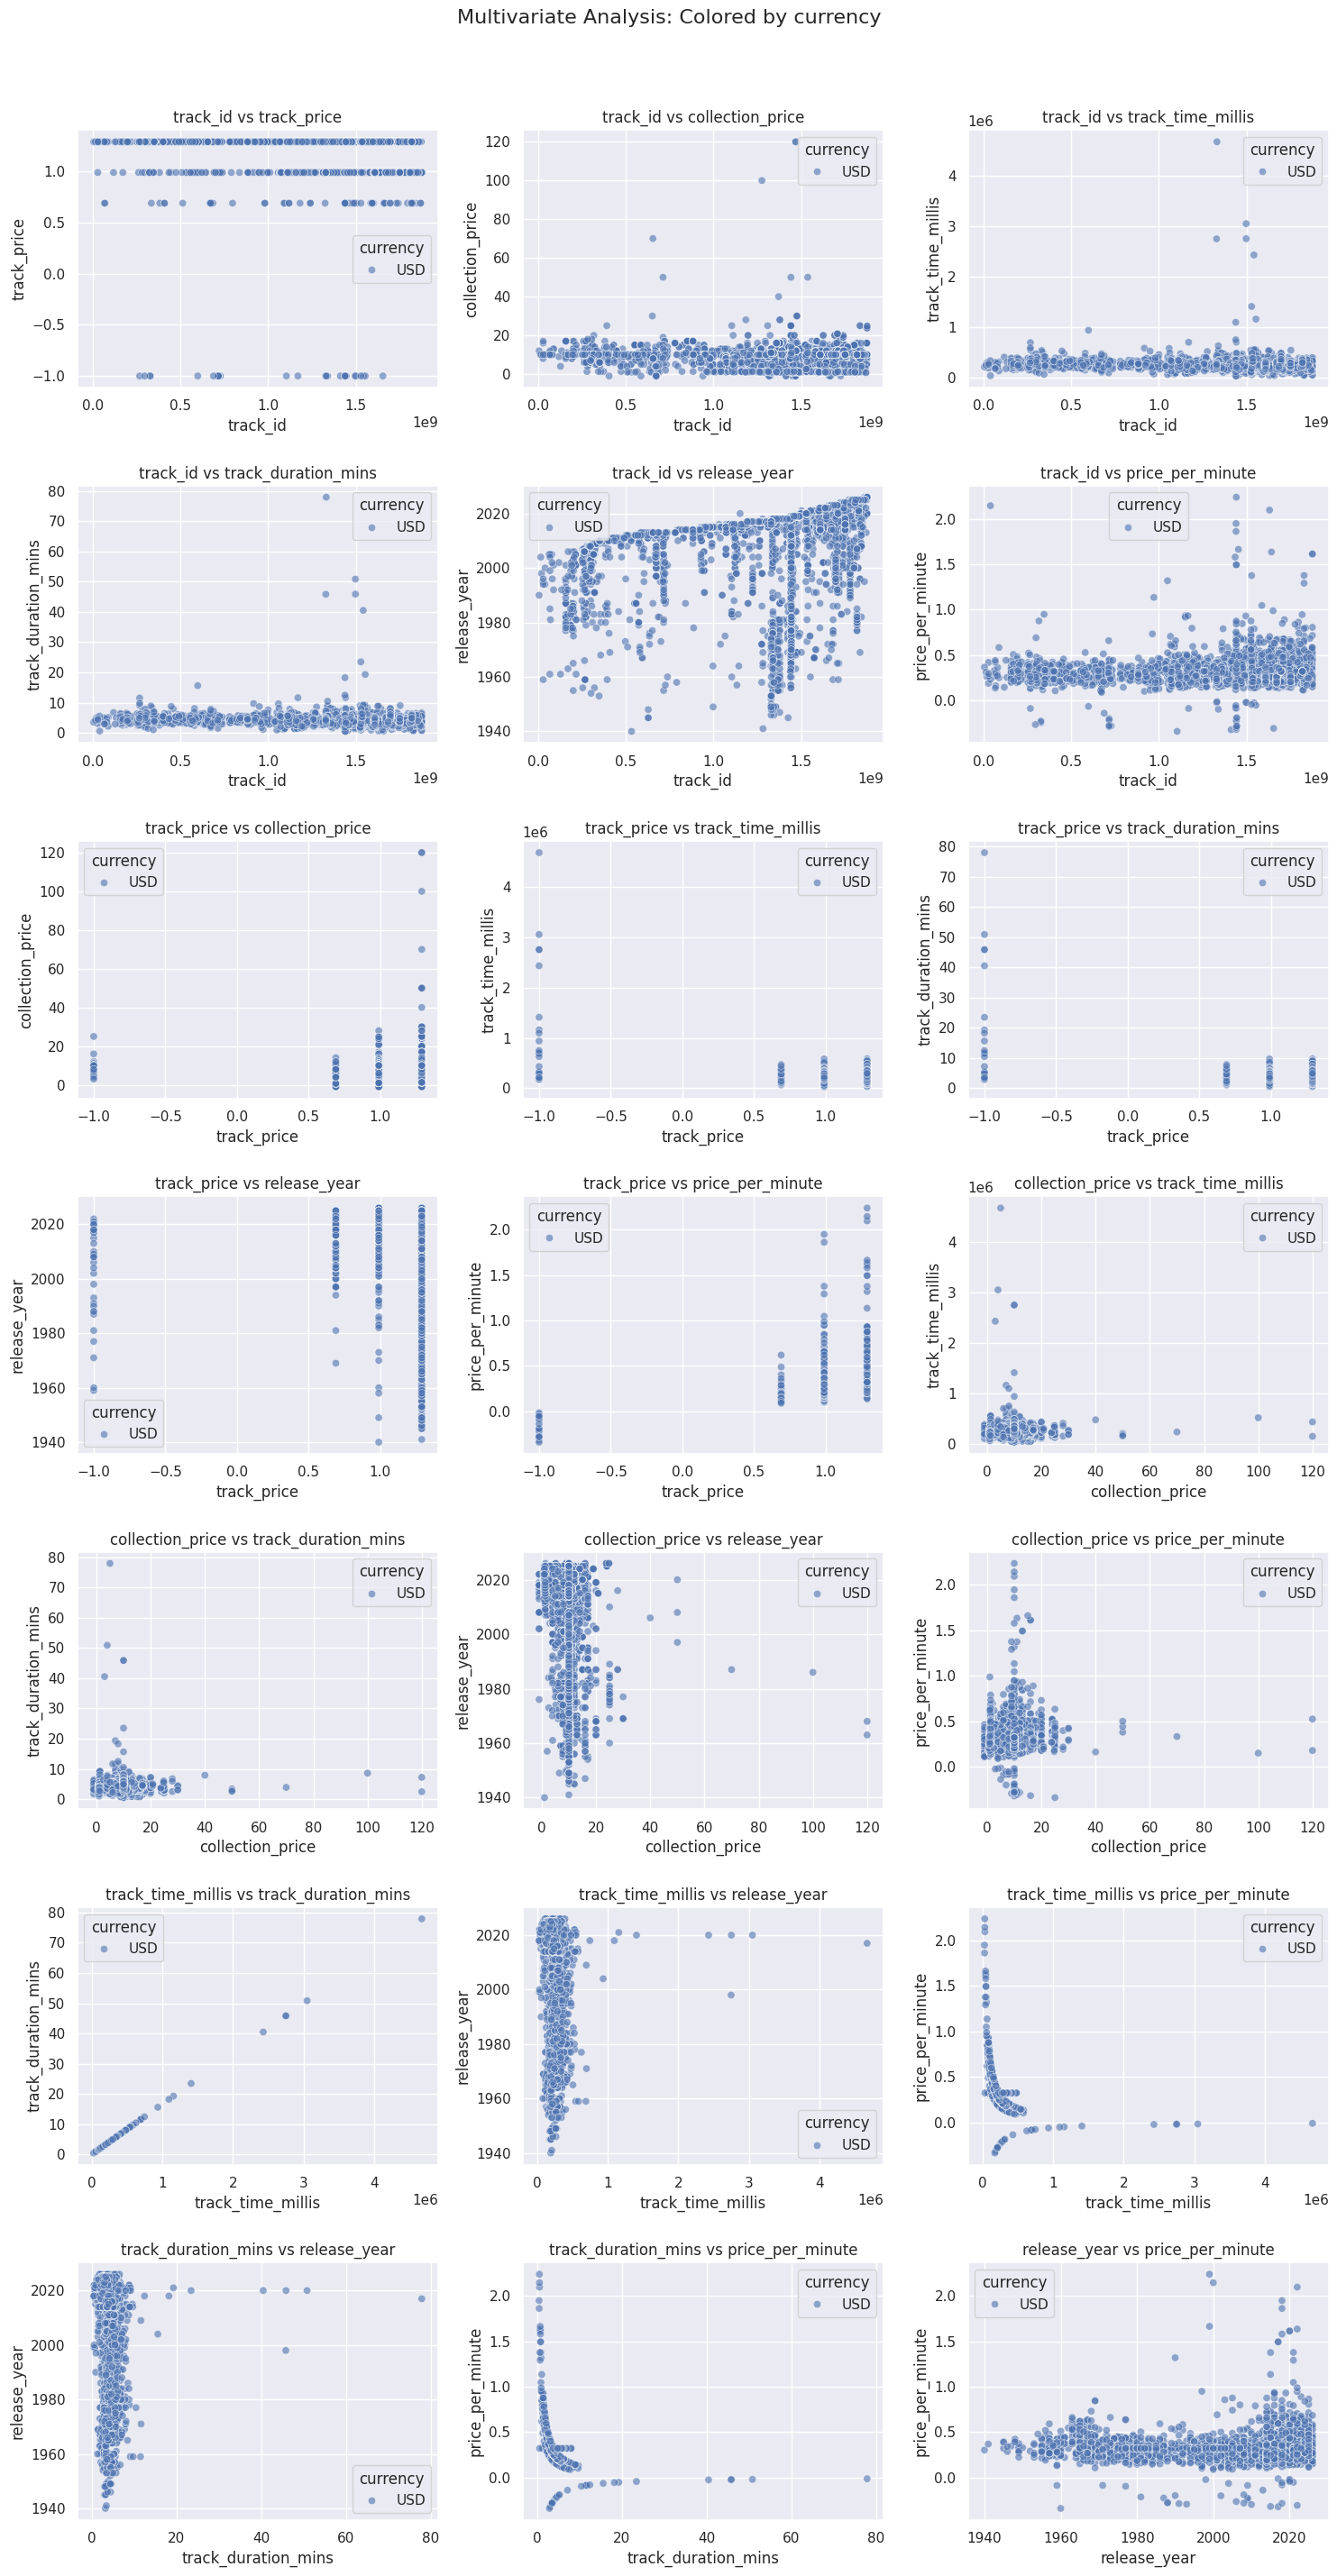

In [ ]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Univariate Analysis

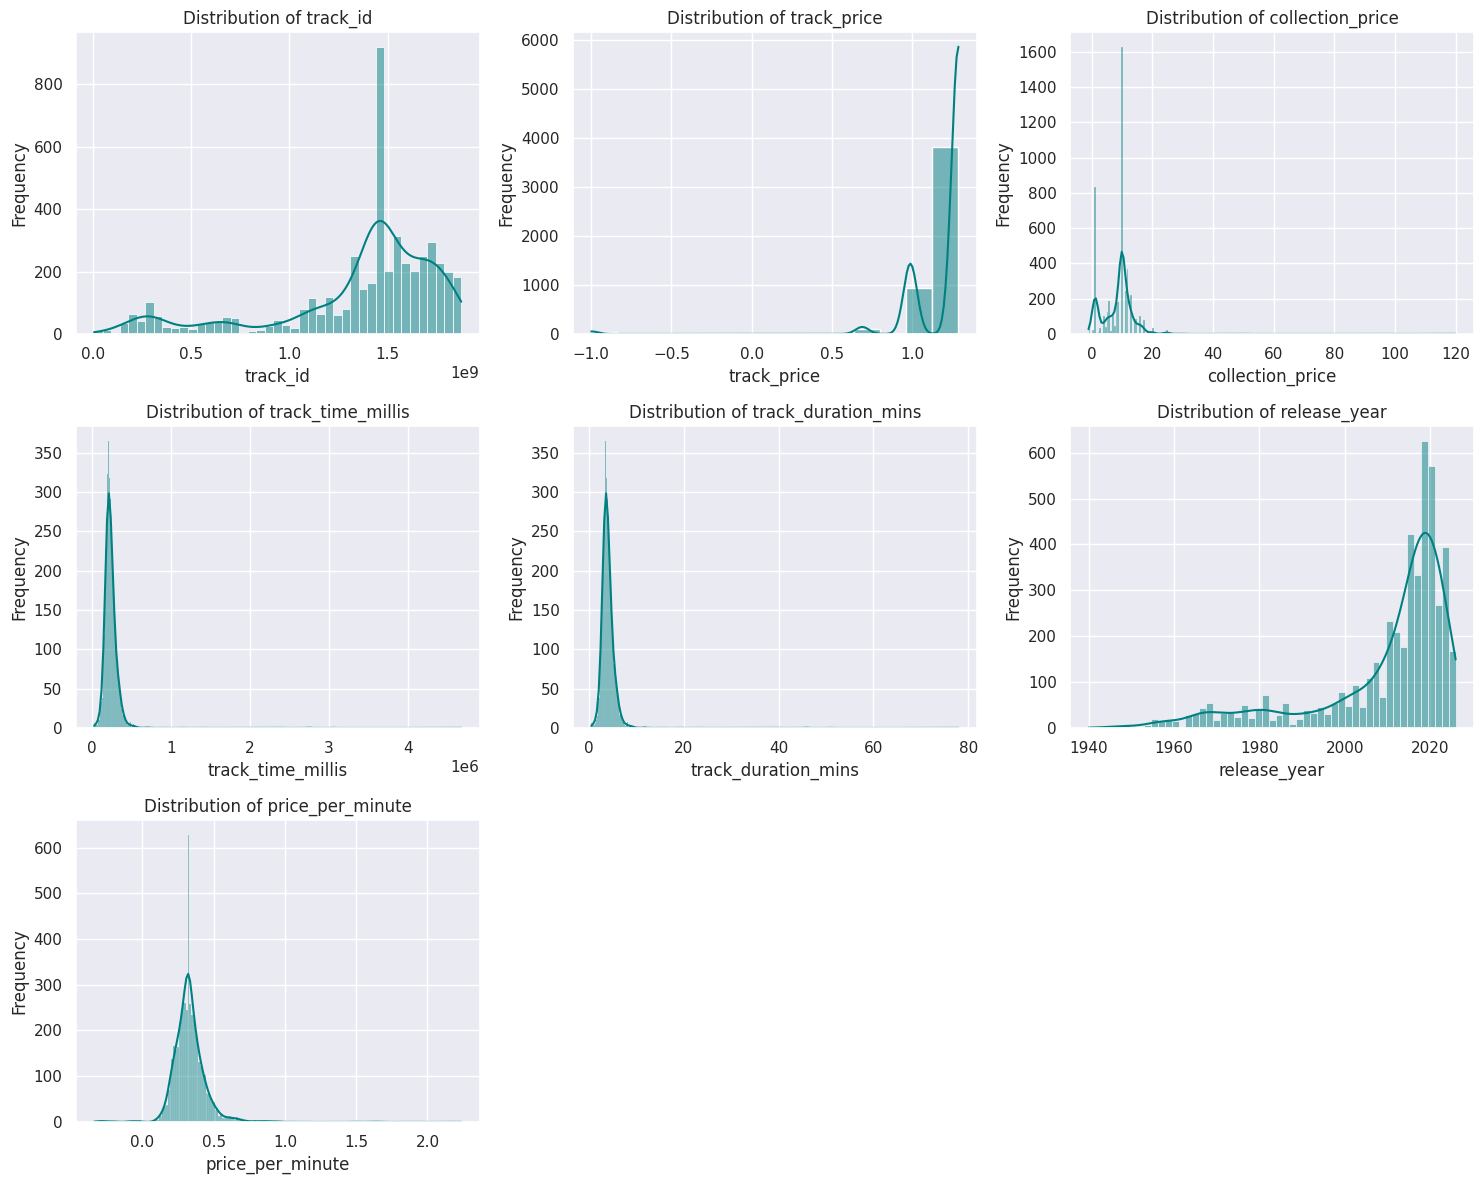

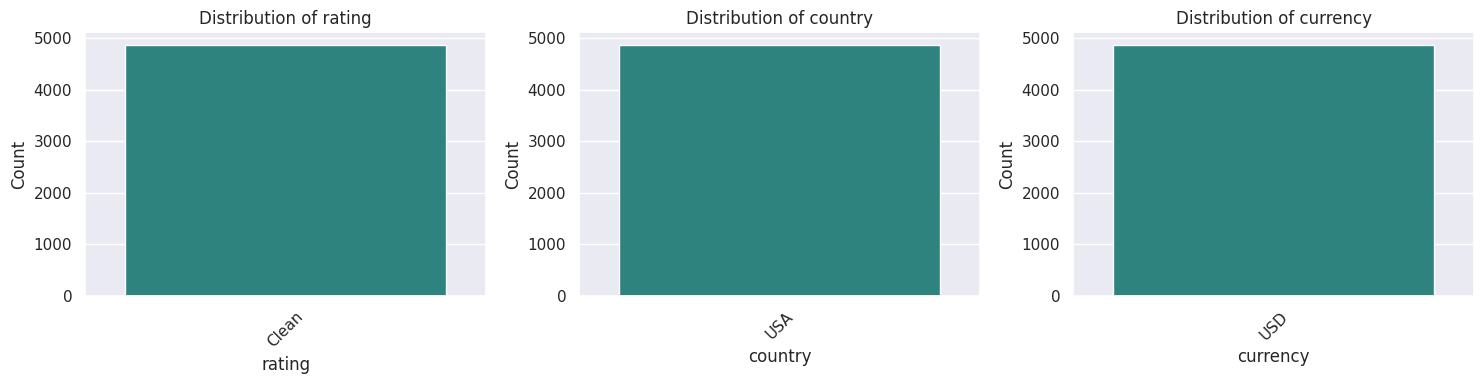

--- Categorical Value Counts ---

Value counts for rating:
rating
Clean    4865
Name: count, dtype: int64

Value counts for country:
country
USA    4865
Name: count, dtype: int64

Value counts for currency:
currency
USD    4865
Name: count, dtype: int64


In [ ]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

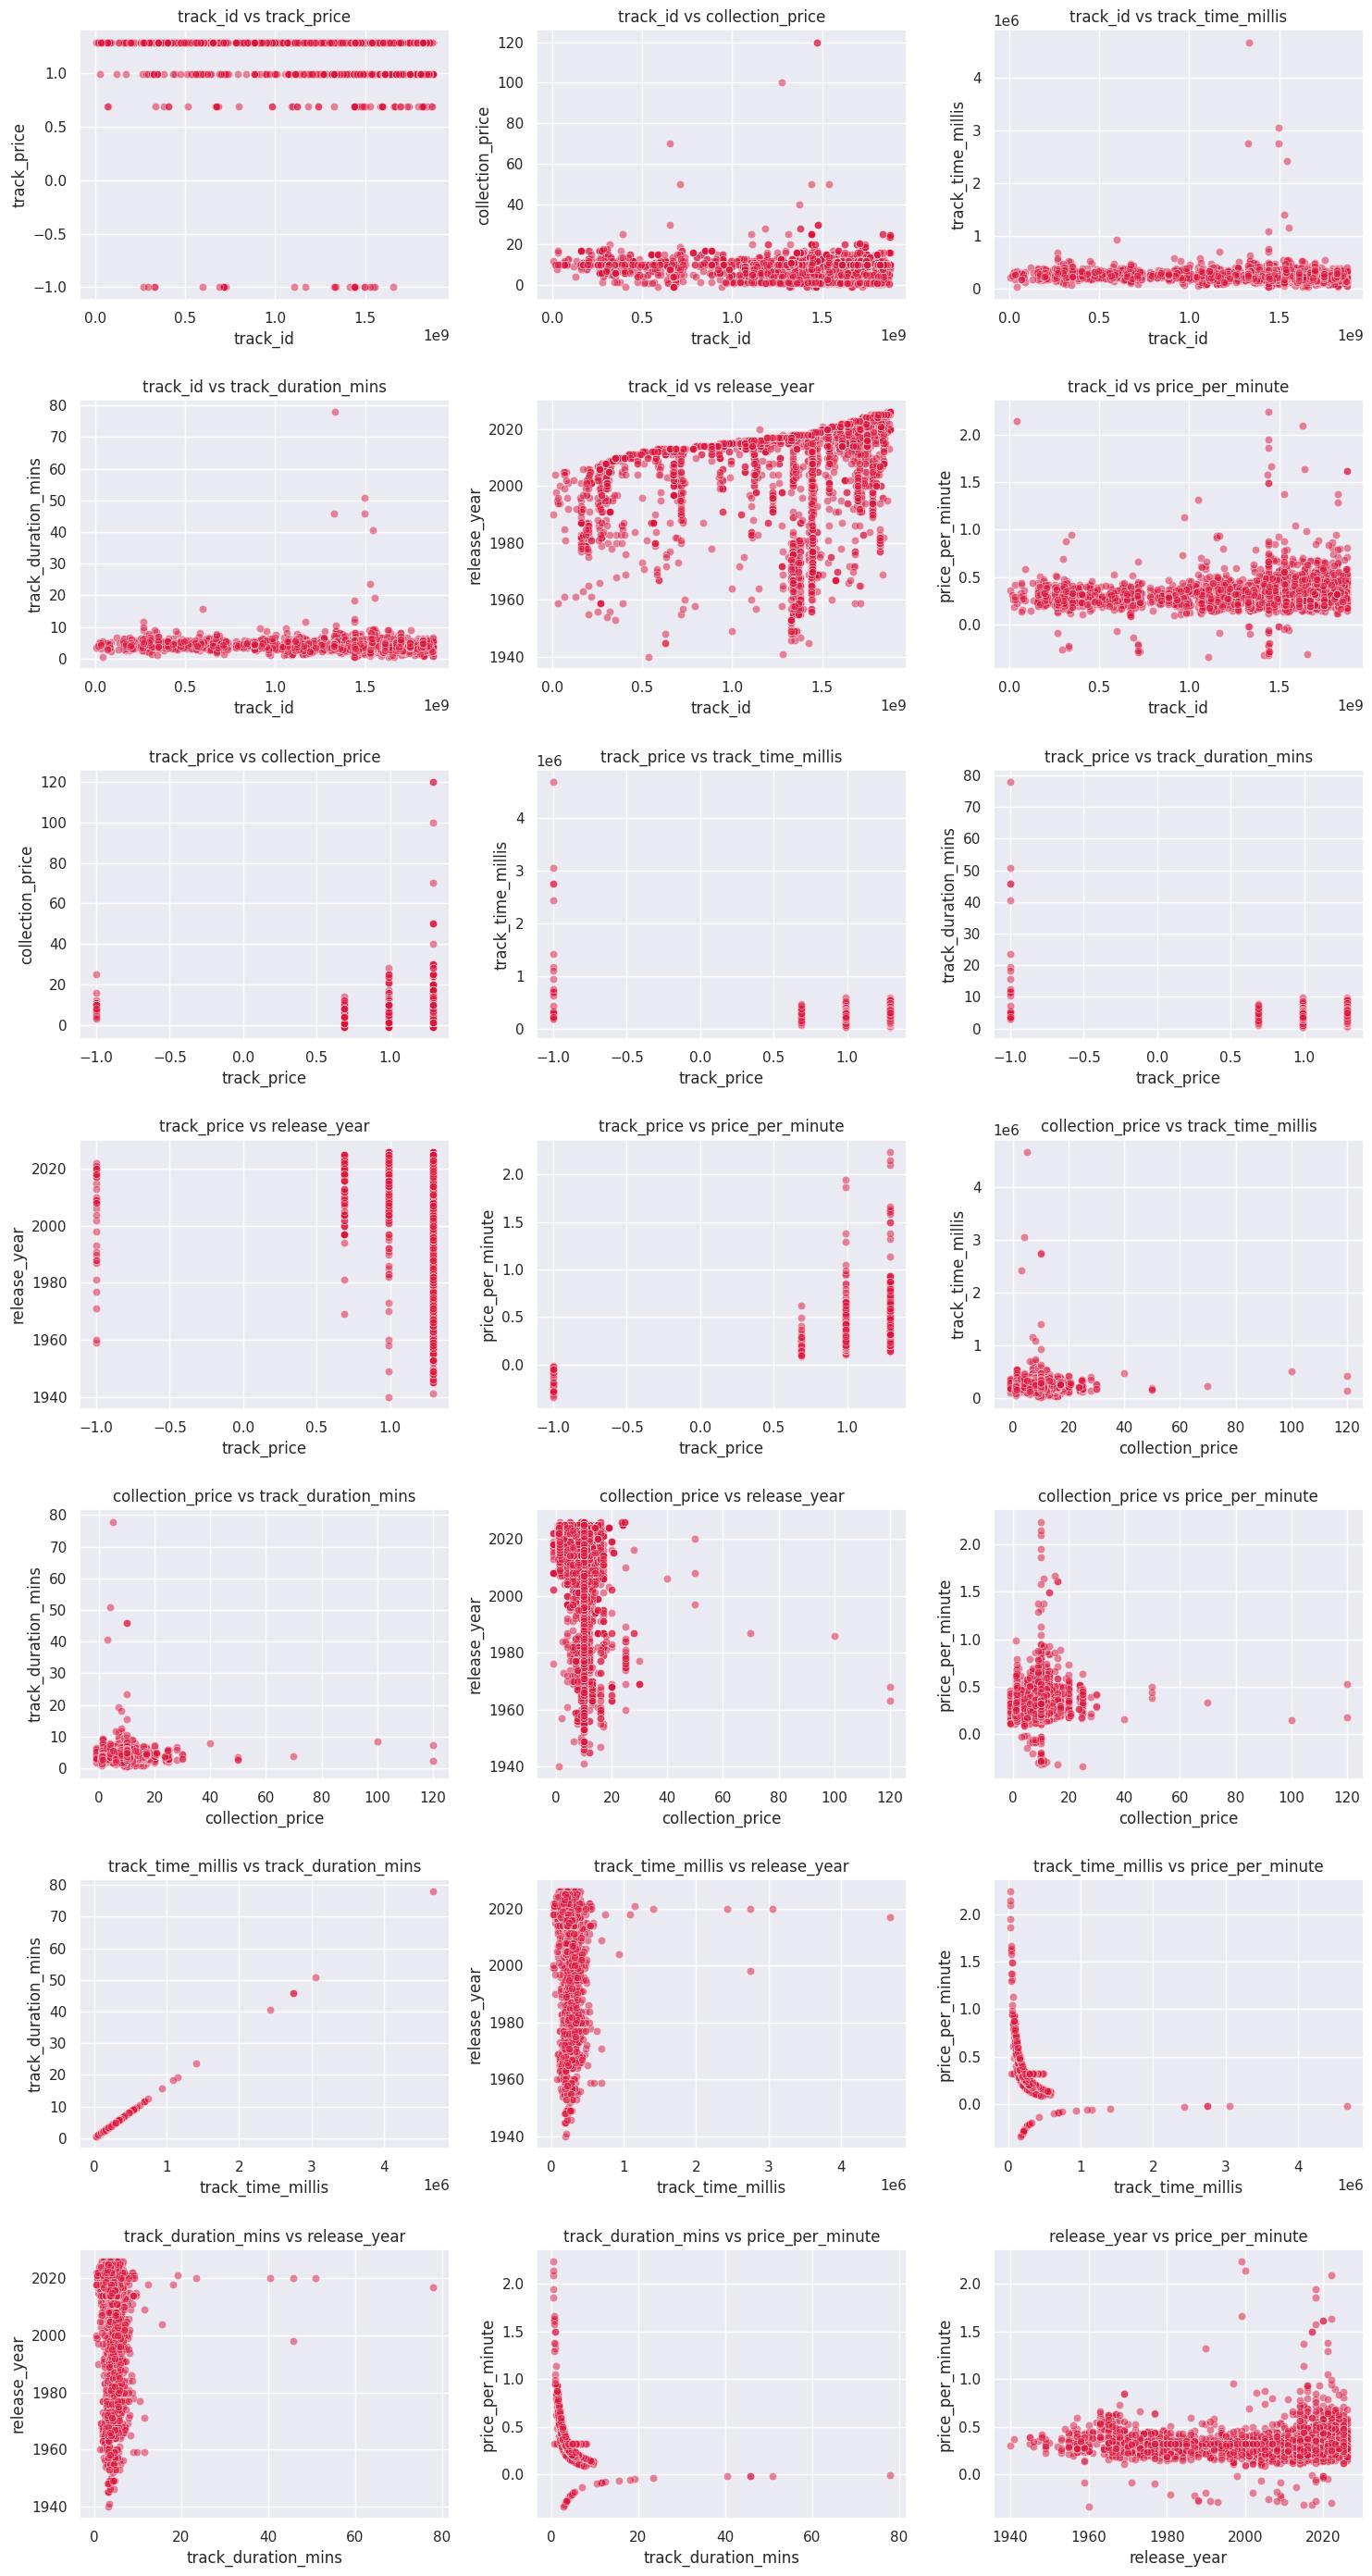

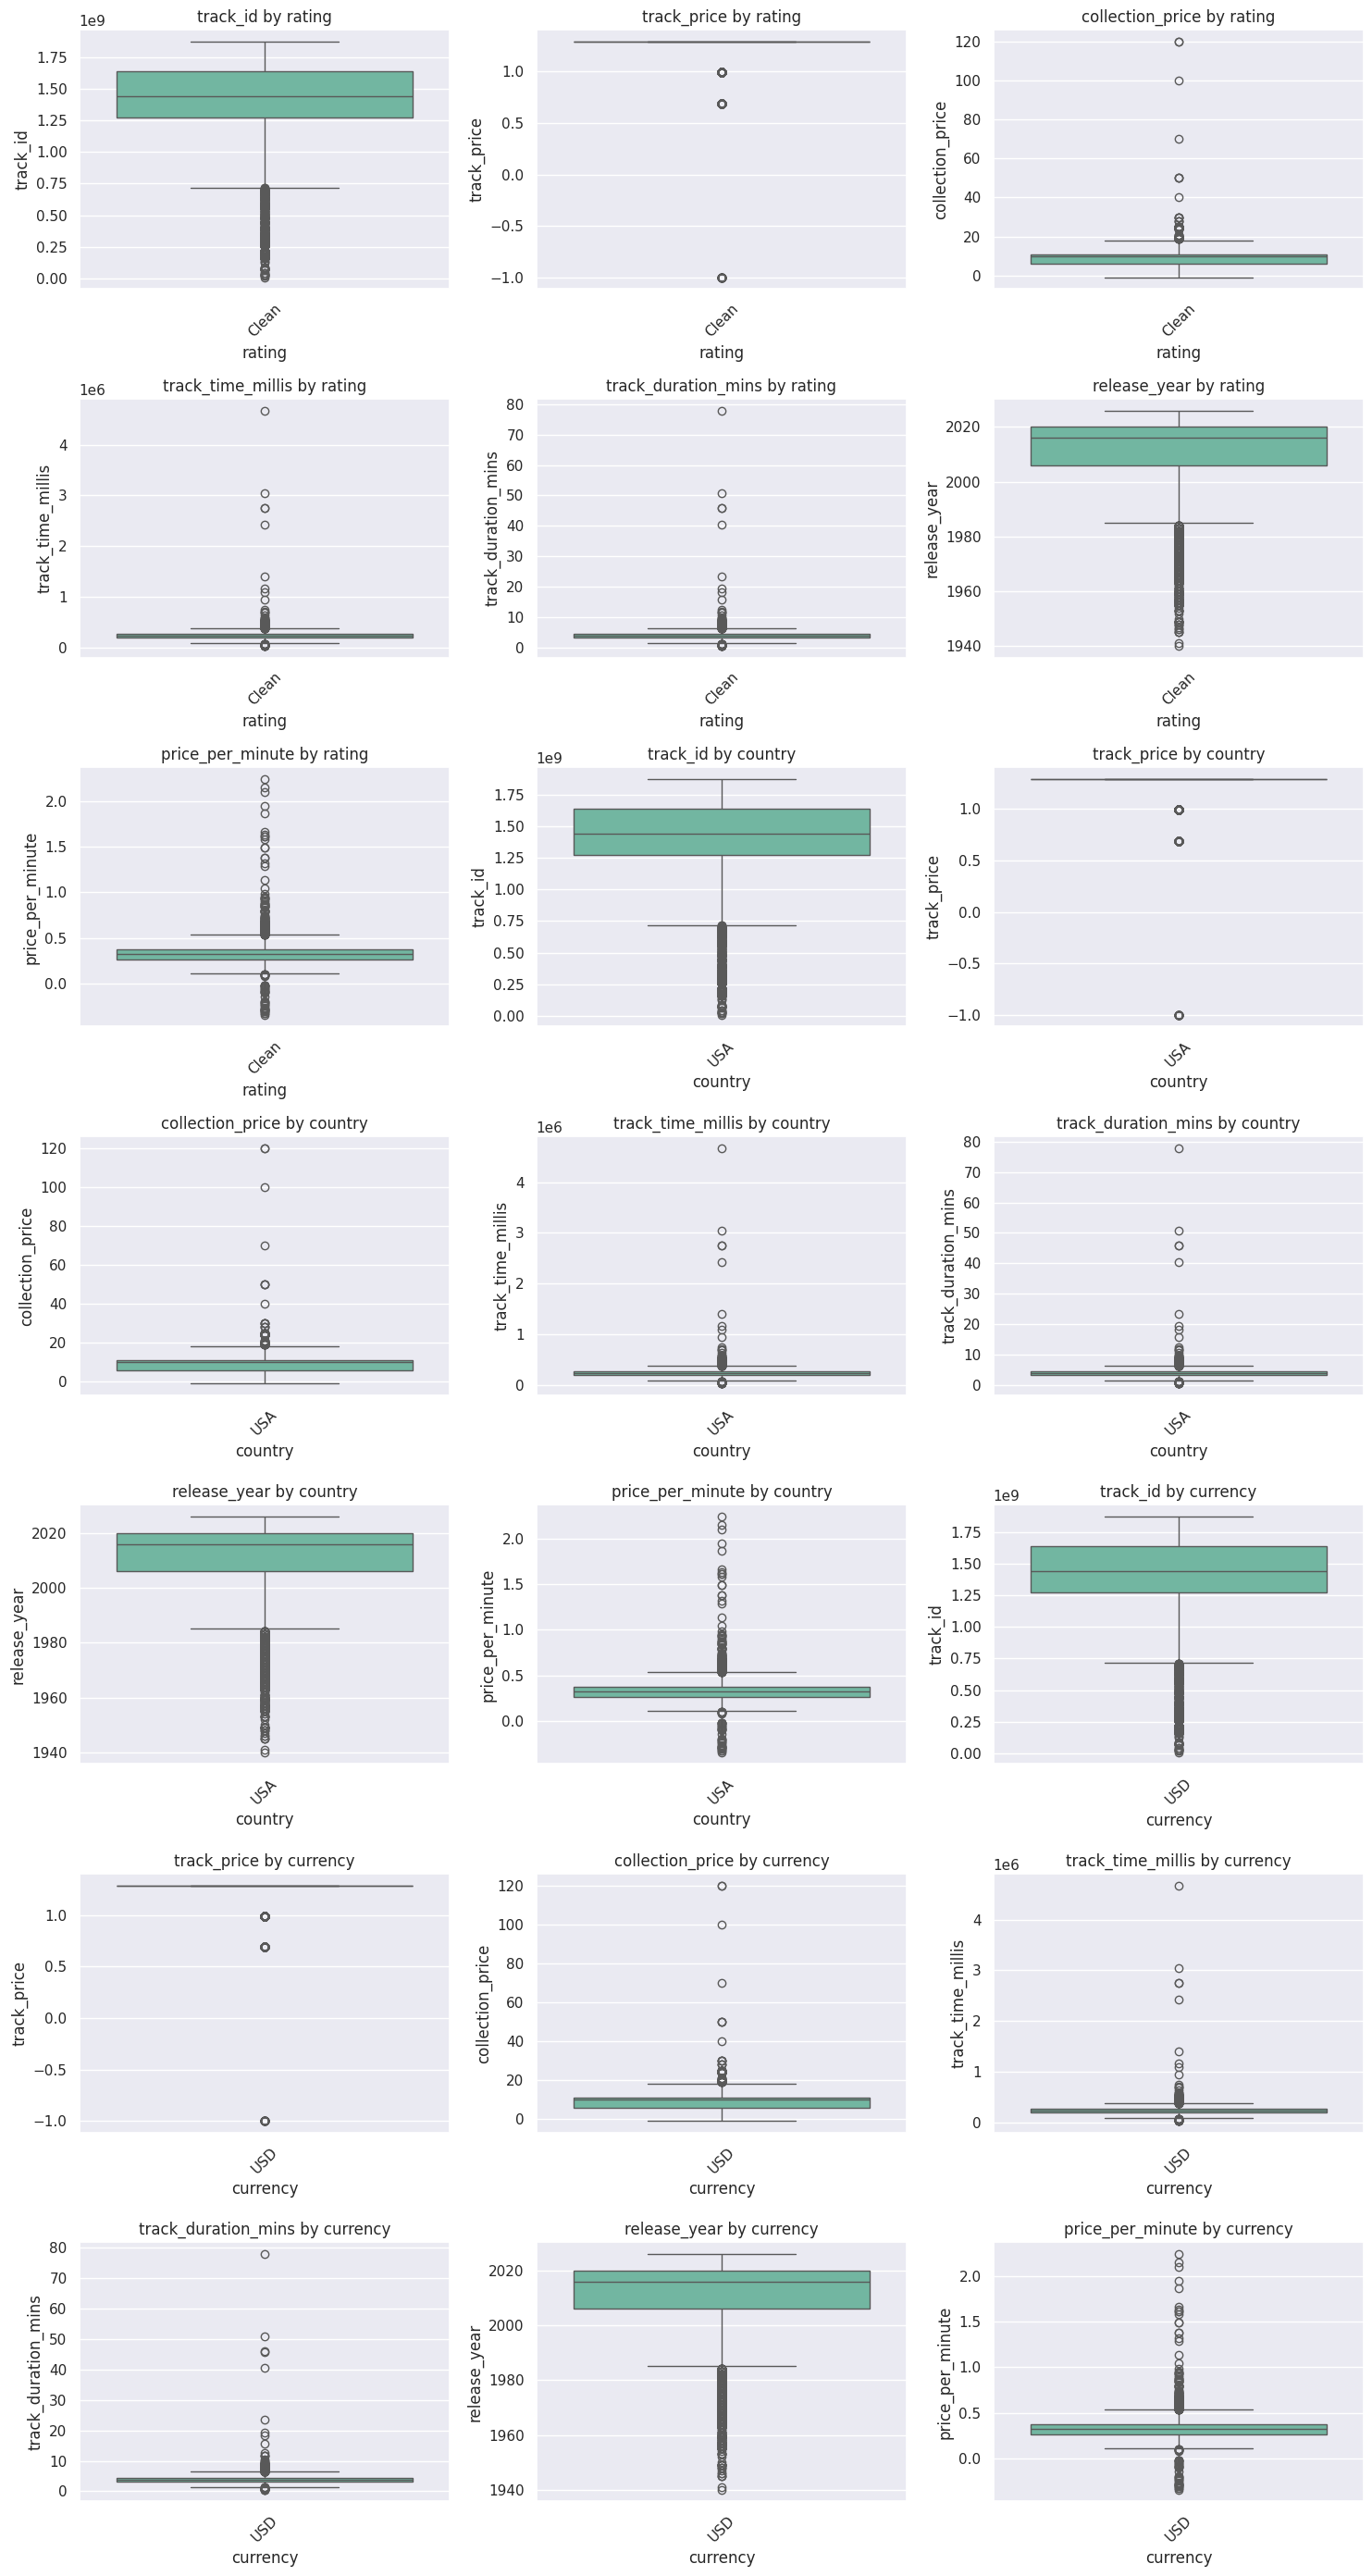

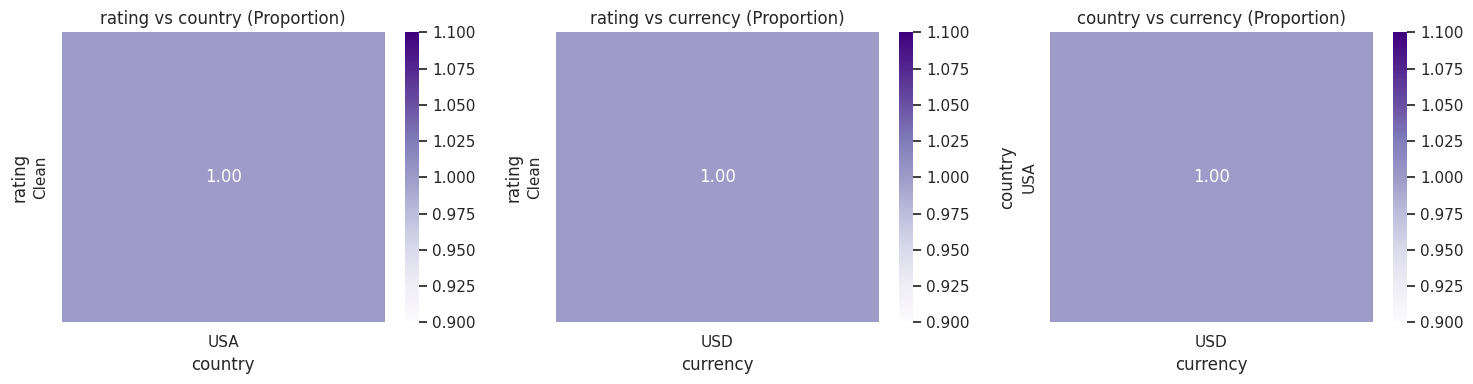

In [ ]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

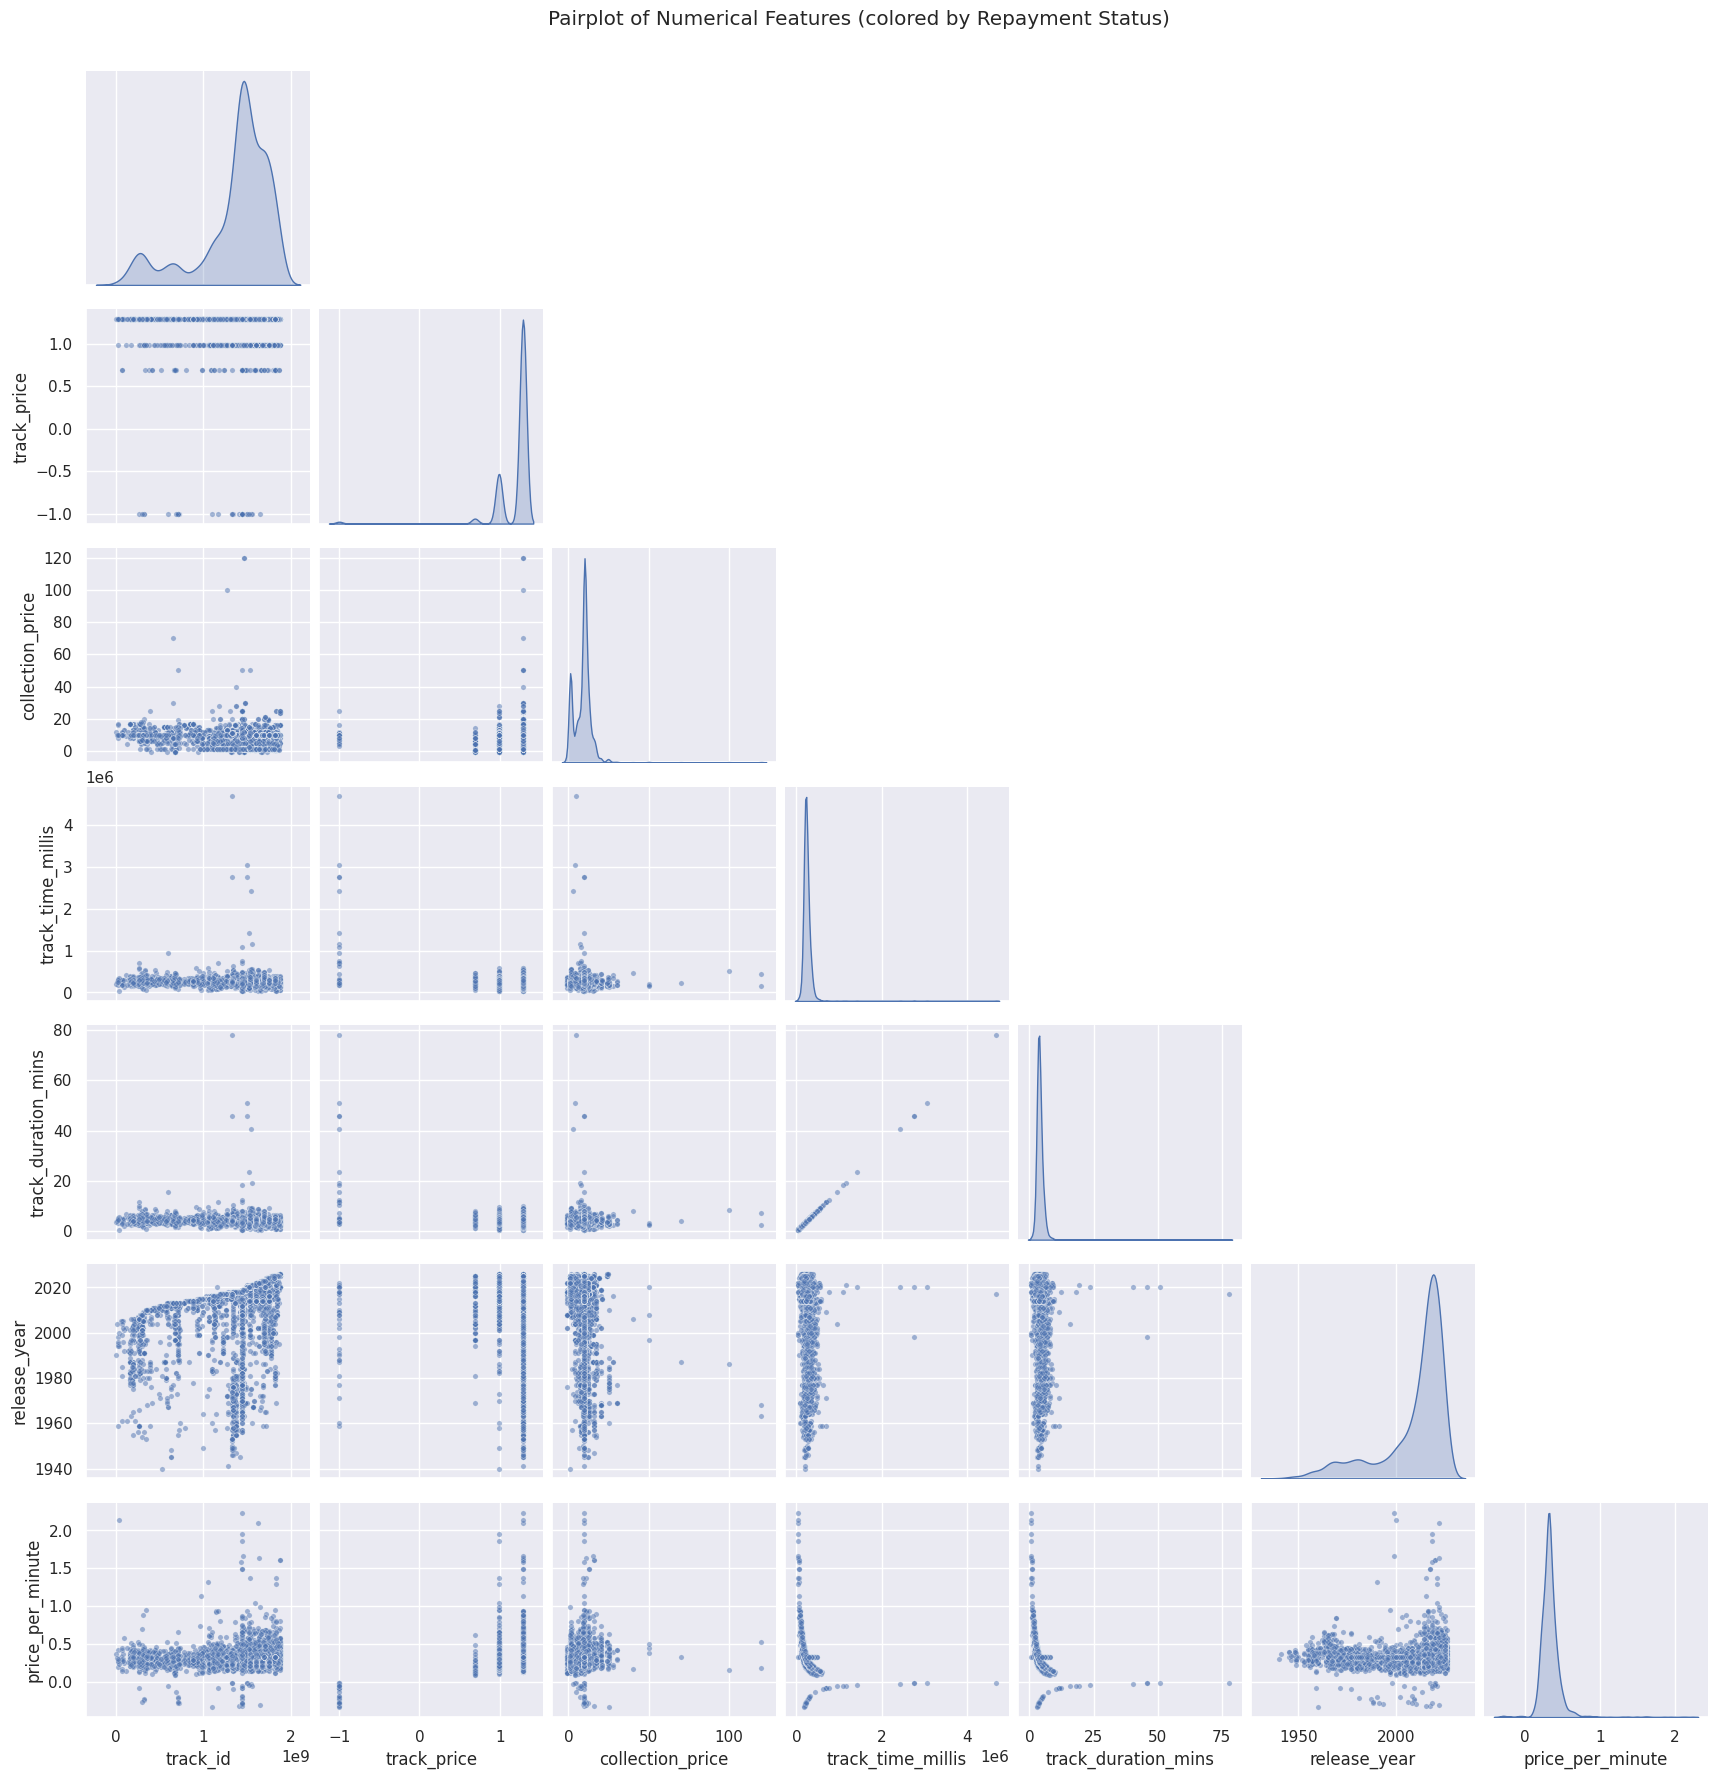

In [ ]:
# Selecting numerical columns
vars_to_plot = df.select_dtypes(include=np.number).columns.tolist()

# Checking if Repayment_Status exists to use as hue
hue_col = 'Repayment_Status' if 'Repayment_Status' in df.columns else None

# Creating the pairplot
sns.pairplot(
    df,
    vars=vars_to_plot,
    hue=hue_col,
    corner=True,
    palette='bright',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15}
)

plt.suptitle('Pairplot of Numerical Features (colored by Repayment Status)', y=1.02)
plt.show()

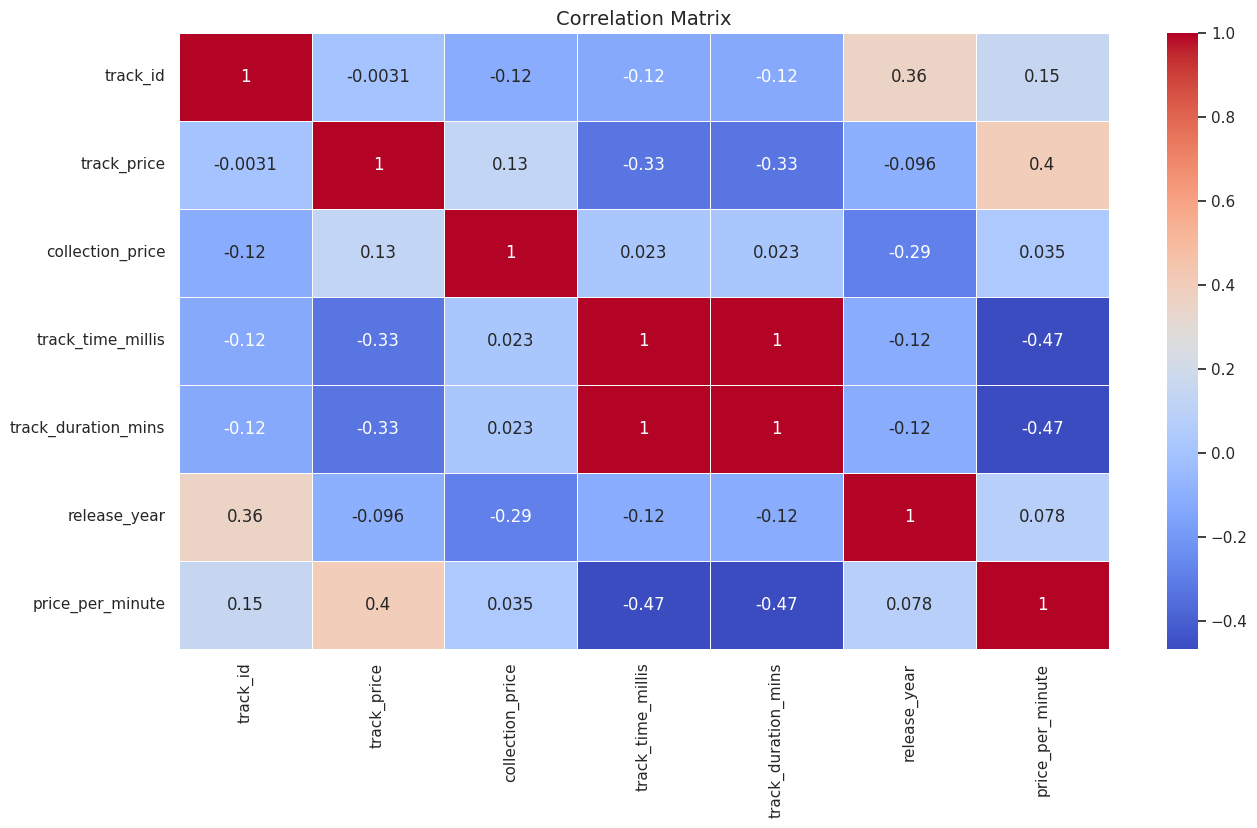

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Feature Engineering | Audio Analysis

In [ ]:
print("--- 1. TIME FORMATTING ---")
# 'track_time_millis' is impossible for a human to read. Let's convert it to minutes.
df['track_duration_mins'] = df['track_time_millis'] / 60000
print("✅ Created: 'track_duration_mins' (Human readable track length)")

print("\n--- 2. TIMELINE EXTRACTION ---")
# The release_date column is currently a string. I need to convert it to a true datetime object
# so I can extract just the year. This lets me analyze historical music trends.
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
print("✅ Created: 'release_year'")

print("\n--- 3. MUSIC ECONOMICS ---")
# How much are people paying per minute of audio?
# A 2-minute pop song for $1.29 is vastly more expensive per minute than a 10-minute classical piece.
df['price_per_minute'] = np.where(
    df['track_duration_mins'] > 0,
    df['track_price'] / df['track_duration_mins'],
    0
)
print("✅ Created: 'price_per_minute'")

# Let's check our new columns
print("\n--- NEW FEATURES REVIEW ---")
print(df[['track_name', 'genre', 'track_duration_mins', 'release_year', 'price_per_minute']].head())

--- 1. TIME FORMATTING ---
✅ Created: 'track_duration_mins' (Human readable track length)

--- 2. TIMELINE EXTRACTION ---
✅ Created: 'release_year'

--- 3. MUSIC ECONOMICS ---
✅ Created: 'price_per_minute'

--- NEW FEATURES REVIEW ---
                 track_name        genre  track_duration_mins  release_year  \
0                      POP!        Dance             2.801783          2022   
1                   Riptide  Alternative             3.366983          2013   
2  Something Just Like This        Dance             4.119417          2017   
3                    lovely          Pop             3.336450          2018   
4     when the party's over  Alternative             3.267950          2018   

   price_per_minute  
0          0.460421  
1          0.383132  
2          0.313151  
3          0.386638  
4          0.394743  


# Statistical Analysis

--- 1. THE 'TIKTOK EFFECT' (PEARSON CORRELATION) ---
Pearson Correlation Coefficient: -0.1171
P-Value: 2.5270e-16
✅ Insight: The correlation is statistically significant!
 -> THE TIKTOK EFFECT IS REAL: As the years go on, track lengths are getting shorter.


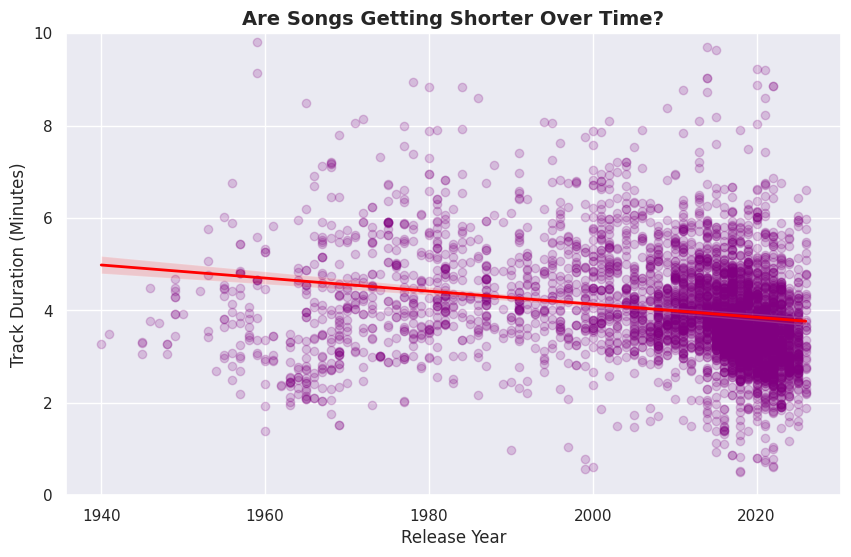


--- 2. THE GENRE DURATION TEST (ANOVA) ---
Testing the Top 5 Genres: ['Bollywood', 'Pop', 'R&B/Soul', 'Hip-Hop/Rap', 'Rock']
ANOVA P-Value: 2.2874e-31
✅ Insight: Genre heavily dictates how long a song will be.


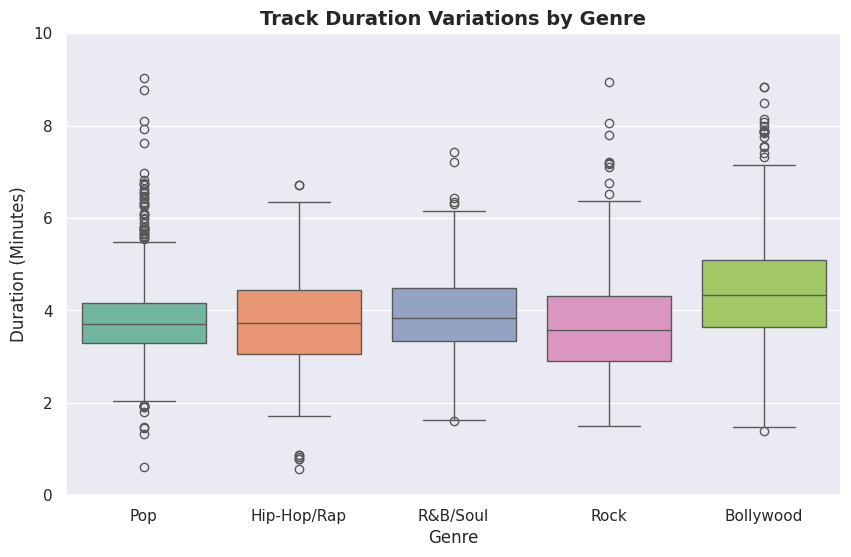

In [ ]:
import scipy.stats as stats

print("--- 1. THE 'TIKTOK EFFECT' (PEARSON CORRELATION) ---")

trend_data = df[['release_year', 'track_duration_mins']].dropna()

# We use Pearson to check if as the Year goes UP, the Duration goes DOWN
corr_coef, p_val_corr = stats.pearsonr(trend_data['release_year'], trend_data['track_duration_mins'])

print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-Value: {p_val_corr:.4e}")

if p_val_corr < 0.05:
    print("✅ Insight: The correlation is statistically significant!")
    if corr_coef < 0:
        print(" -> THE TIKTOK EFFECT IS REAL: As the years go on, track lengths are getting shorter.")
    else:
        print(" -> Tracks are actually getting longer over the years.")
else:
    print("❌ Insight: Track lengths have stayed relatively constant over time. The year doesn't dictate the length.")

# Visualizing the timeline of track durations
plt.figure(figsize=(10, 6))
sns.regplot(
    x='release_year',
    y='track_duration_mins',
    data=trend_data,
    scatter_kws={'alpha':0.2, 'color':'purple'},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Are Songs Getting Shorter Over Time?', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Track Duration (Minutes)', fontsize=12)
plt.ylim(0, 10)
plt.show()


print("\n--- 2. THE GENRE DURATION TEST (ANOVA) ---")

top_genres = df['genre'].value_counts().head(5).index.tolist()
print(f"Testing the Top 5 Genres: {top_genres}")

# I'm grouping the track durations by these specific genres
genre_groups = [df[df['genre'] == genre]['track_duration_mins'].dropna() for genre in top_genres]

# Running a One-Way ANOVA test to compare multiple groups at once
f_stat, p_val_anova = stats.f_oneway(*genre_groups)

print(f"ANOVA P-Value: {p_val_anova:.4e}")
if p_val_anova < 0.05:
    print("✅ Insight: Genre heavily dictates how long a song will be.")

    # Let's visualize the differences we just proved
    plt.figure(figsize=(10, 6))
    # I'm filtering the dataframe to only show the top 5 genres
    df_top_genres = df[df['genre'].isin(top_genres)]
    sns.boxplot(x='genre', y='track_duration_mins', data=df_top_genres, palette='Set2')

    plt.title('Track Duration Variations by Genre', fontsize=14, fontweight='bold')
    plt.xlabel('Genre', fontsize=12)
    plt.ylabel('Duration (Minutes)', fontsize=12)
    plt.ylim(0, 10) # Zooming in on the bulk of the data
    plt.show()
else:
    print("❌ Insight: All the top genres share roughly the same average track length.")

# Machine Learning | Genre

--- 1. PREPARING FOR THE CLASSIFICATION EXAM ---
Our AI will try to predict between: ['Bollywood', 'Pop', 'R&B/Soul']
✅ Data successfully split into Study and Exam sets.

--- 2. TRAINING ---
✅ Random Forest model has been trained.

--- 3. GRADING THE EXAM (THE CONFUSION MATRIX) ---
🎯 Overall Model Accuracy: 67.71%



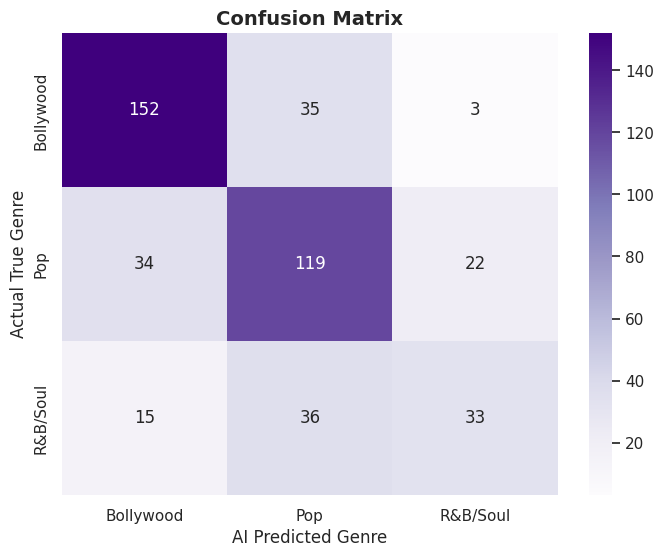


📊 Detailed Diagnostic Report:
              precision    recall  f1-score   support

   Bollywood       0.76      0.80      0.78       190
         Pop       0.63      0.68      0.65       175
    R&B/Soul       0.57      0.39      0.46        84

    accuracy                           0.68       449
   macro avg       0.65      0.62      0.63       449
weighted avg       0.67      0.68      0.67       449


--- 4. WHAT DROVE THE DECISION? (FEATURE IMPORTANCE) ---


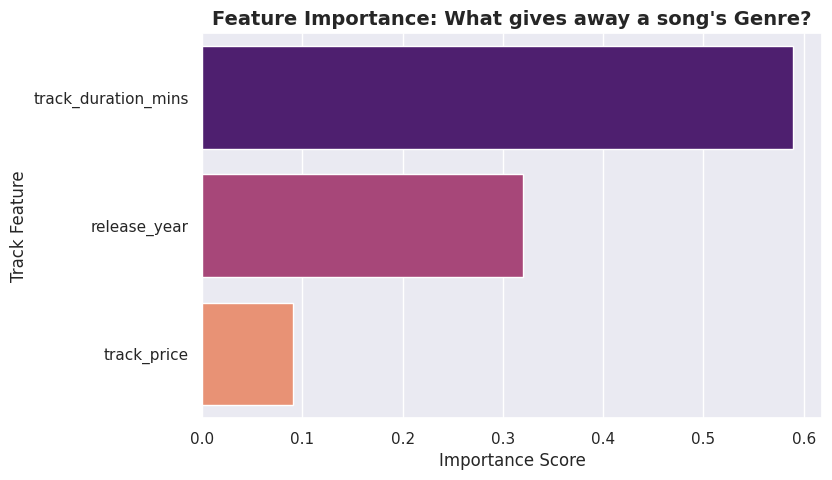

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("--- 1. PREPARING FOR THE CLASSIFICATION EXAM ---")
# I want to see if an AI can guess a song's genre just by looking at its math (Duration, Price, Year).
# To make this a fair test, I am only going to use the top 3 most popular genres.

top_3_genres = df['genre'].value_counts().head(3).index.tolist()
print(f"Our AI will try to predict between: {top_3_genres}")

# Filtering the dataset to only include these 3 genres
ml_class_data = df[df['genre'].isin(top_3_genres)].dropna(subset=['track_duration_mins', 'release_year', 'track_price']).copy()

# Definning our Features (The Clues) and our Target (The Answer Key)
features = ['track_duration_mins', 'release_year', 'track_price']
X = ml_class_data[features]
y = ml_class_data['genre']

# Spliting the data: 80% for to study, 20% for the final exam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Data successfully split into Study and Exam sets.")


print("\n--- 2. TRAINING ---")
# Using a Random Forest Classifier because it is highly accurate
# And explicitly tells us which features it used to make its decisions.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
print("✅ Random Forest model has been trained.")


print("\n--- 3. GRADING THE EXAM (THE CONFUSION MATRIX) ---")
y_pred = rf_classifier.predict(X_test)

# Calculating standard accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Overall Model Accuracy: {accuracy * 100:.2f}%\n")
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=top_3_genres)

# Plotting the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=top_3_genres, yticklabels=top_3_genres)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('AI Predicted Genre', fontsize=12)
plt.ylabel('Actual True Genre', fontsize=12)
plt.show()

# Printing the detailed breakdown
print("\n📊 Detailed Diagnostic Report:")
print(classification_report(y_test, y_pred, target_names=top_3_genres))


print("\n--- 4. WHAT DROVE THE DECISION? (FEATURE IMPORTANCE) ---")
# Did it rely heavily on the track length, or the release year?

importances = pd.Series(rf_classifier.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Feature Importance: What gives away a song\'s Genre?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Track Feature', fontsize=12)
plt.show()

# Thank You